In [2]:
from rdkit import Chem
from rdkit.Chem import RDConfig
import os, sys
sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score"))
import sascorer

Using SA: Proxy (heuristic)
Selected 4 molecules for MD (target=4).


,SMILES,Surfactant_Type,True_Value,Predicted_Value,SA,CMC_bin,Set
0,CCCCCCOC(=O)CS(=O)(=O)[O-].[Na+],anionic,2.230449,2.358489,2.080900,2,Test
1,CCCCCCCCCCCCCC[N+](C)(C)C.[Br-],cationic,0.556303,0.575280,2.890000,0,Test
2,CCCCCCCCCCOCCOCCOCCOCCO,nonionic,-0.168770,-0.245459,3.970000,1,Test
3,CCCCCCCCCCCCCCCC[N+](C)(C)CC(=O)[O-],zwitterionic,-1.698970,-1.036913,3.580876,0,Test


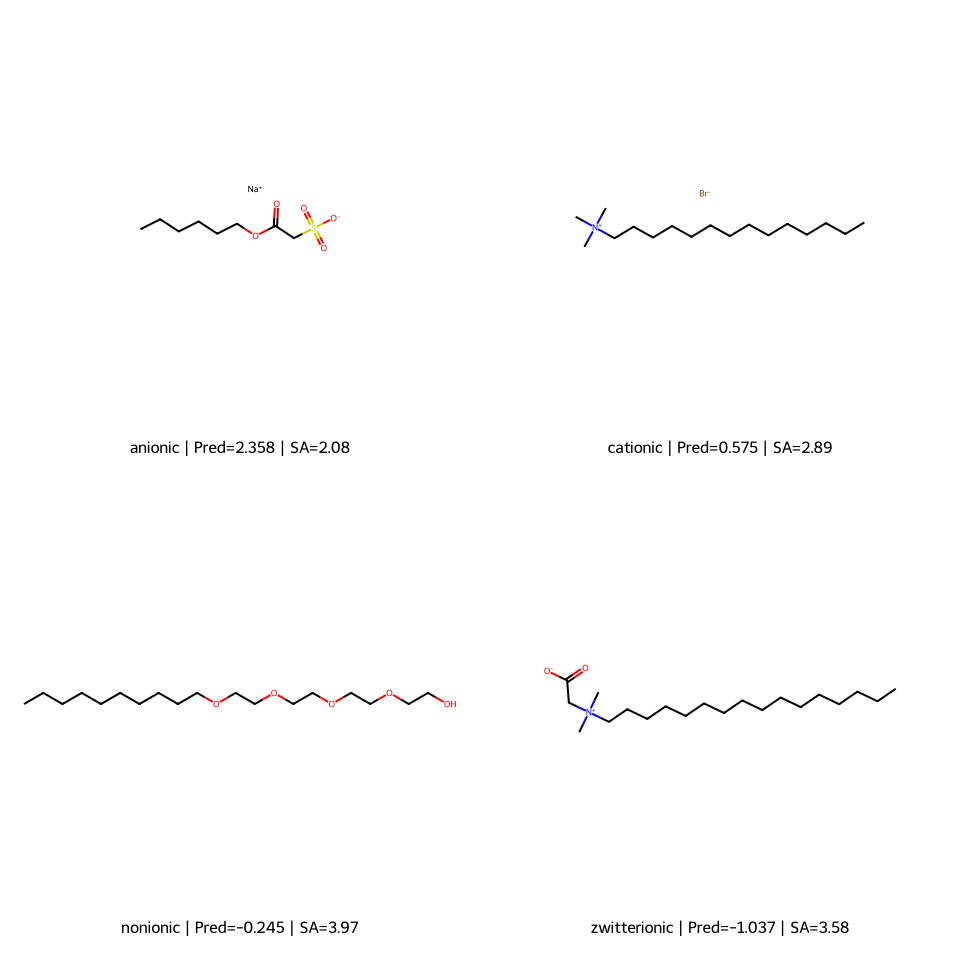


Saved selection to: ../models/surfactant_model_data2_newSplit70_20_10_plot_opt_R9/seed_2022/fold_0/results\selected_for_MD2.csv


In [4]:
# === MD Selection for Your CSV (surfactants) ===
# Columns expected: SMILES, True_Value, Predicted_Value, Set, Surfactant_Type

import os, sys, math
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors as rdMD
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem import Draw

# --------------- INPUT ---------------
CSV = r"../models/surfactant_model_data2_newSplit70_20_10_plot_opt_R9/seed_2022/fold_0/results/predictions_test_data_with_types.csv"
TOTAL_TO_PICK = 4          # total molecules for MD
PER_CATEGORY = True        # try to cover Surfactant_Type (one per type if possible)
CMC_BINS = 3               # split Predicted_Value into low/mid/high bins
SA_SOFT_CAP = 6.0          # soft preference for SA <= this (no hard filter)
RANDOM_STATE = 2022

# --------------- OPTIONAL: exact SA scorer (Ertl) ---------------
candidate_paths = [
    ".", "/content", "/content/drive/MyDrive",
    "/content/drive/MyDrive/surfactants",
    "/content/drive/MyDrive/surfactants/utils",
    os.path.dirname(CSV),
]
_sascorer = None
for p in candidate_paths:
    f = os.path.join(p, "sascorer.py")
    if os.path.exists(f):
        if p not in sys.path:
            sys.path.insert(0, p)
        try:
            import sascorer as _sascorer
        except Exception:
            _sascorer = None
        break

def _num_stereo(m):
    try:
        return rdMD.CalcNumAtomStereoCenters(m)
    except TypeError:
        return len(Chem.FindMolChiralCenters(m, includeUnassigned=True, useLegacyImplementation=False))

def _sa_proxy(m):
    # A simple SA-like complexity proxy (1..10), tuned to penalize rings/size/flexibility.
    n_heavy   = rdMD.CalcNumHeavyAtoms(m)
    n_rings   = rdMD.CalcNumRings(m)
    n_aromR   = rdMD.CalcNumAromaticRings(m)
    n_aliphR  = rdMD.CalcNumAliphaticRings(m)
    n_bridge  = rdMD.CalcNumBridgeheadAtoms(m)
    n_spiro   = rdMD.CalcNumSpiroAtoms(m)
    n_stereo  = _num_stereo(m)
    n_rotb    = rdMD.CalcNumRotatableBonds(m)
    fsp3      = rdMD.CalcFractionCSP3(m)
    tpsa      = rdMD.CalcTPSA(m)
    molwt     = Descriptors.MolWt(m)
    logp      = Crippen.MolLogP(m)
    lr_size   = max((len(r) for r in m.GetRingInfo().AtomRings()), default=0)
    macro     = 1 if lr_size >= 12 else 0
    score = 0.0
    score += 0.010 * max(0, n_heavy - 18)
    score += 0.35  * n_rings
    score += 0.25  * n_aromR
    score += 0.15  * n_aliphR
    score += 0.40  * n_bridge
    score += 0.30  * n_spiro
    score += 0.15  * n_stereo
    score += 0.08  * n_rotb
    score += 0.30  * macro
    score += 0.03  * max(0.0, (tpsa - 70)/10.0)
    score += 0.02  * max(0.0, (molwt - 550)/25.0)
    score += 0.50  * max(0.0, 0.60 - fsp3)       # unsaturation penalty
    score += 0.03  * max(0.0, abs(logp) - 3.5)   # extreme logP penalty
    score = 1.0 + 1.8 * score
    return float(min(10.0, max(1.0, score)))

def SA_score(m):
    if _sascorer is not None:
        try:
            return float(_sascorer.calculateScore(m))
        except Exception:
            pass
    return _sa_proxy(m)

# --------------- Diversity helpers ---------------
fpgen = GetMorganGenerator(radius=2, fpSize=2048)
def ecfp4_fp(mol):
    fp = fpgen.GetFingerprint(mol)
    return fp

def tanimoto_distance(fpA, fpB):
    return 1.0 - DataStructs.TanimotoSimilarity(fpA, fpB)

def farthest_point_sampling(fps, k):
    n = len(fps)
    if n == 0: return []
    if k >= n: return list(range(n))
    selected = [0]
    min_dist = np.full(n, np.inf)
    for _ in range(1, k):
        last = selected[-1]
        dists = np.array([tanimoto_distance(fps[last], fps[j]) for j in range(n)])
        min_dist = np.minimum(min_dist, dists)
        # choose farthest item not yet selected
        order = np.argsort(-min_dist)
        next_idx = next(i for i in order if i not in selected)
        selected.append(int(next_idx))
    return selected

def _norm(arr):
    arr = np.asarray(arr, dtype=float)
    if len(arr)==0: return arr
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo + 1e-9)

# --------------- Load & clean data ---------------
df = pd.read_csv(CSV)
# Keep only rows with valid SMILES and (optionally) Set == "test"
if "Set" in df.columns:
    # Your file is test-only, but this is safe if you later pass a combined file
    df = df[df["Set"].astype(str).str.lower().eq("test")]

df["Mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
df = df[df["Mol"].notna()].reset_index(drop=True)

# Attach SA (complexity proxy), treat Predicted_Value as the prediction to stratify
df["SA"] = df["Mol"].apply(SA_score)
df["SA_softflag"] = (df["SA"] <= SA_SOFT_CAP).astype(int)

if "Surfactant_Type" not in df.columns:
    df["Surfactant_Type"] = "ALL"

if "Predicted_Value" not in df.columns:
    raise ValueError("CSV must include 'Predicted_Value' (your model prediction).")

# --------------- Selection logic ---------------
rng = np.random.RandomState(RANDOM_STATE)
types = list(df["Surfactant_Type"].dropna().unique())
types = sorted(types, key=lambda x: str(x))

if not PER_CATEGORY:
    types = ["ALL"]

per_type_target = max(1, TOTAL_TO_PICK // len(types))
remainder = TOTAL_TO_PICK - per_type_target * len(types)

picks = []
for i, t in enumerate(types):
    block = df if t == "ALL" else df[df["Surfactant_Type"] == t]
    if len(block) == 0:
        continue

    # Bin by Predicted_Value (low/mid/high) to cover CMC spectrum
    q = np.linspace(0, 1, CMC_BINS+1)
    edges = block["Predicted_Value"].quantile(q).values
    edges[0] = -np.inf; edges[-1] = np.inf
    block = block.copy()
    block["CMC_bin"] = pd.cut(block["Predicted_Value"], bins=edges, labels=False, include_lowest=True)

    target_k = per_type_target + (1 if i < remainder else 0)

    # Seed: pick at least 1 per bin (if possible) using priority + FPS
    seed_rows = []
    for b in range(CMC_BINS):
        chunk = block[block["CMC_bin"] == b].copy()
        if len(chunk) == 0: 
            continue
        # Priority: lower SA is better; reward SA <= soft cap a bit
        sa_norm = _norm(chunk["SA"].values)
        priority = (0.95*sa_norm) - 0.05*chunk["SA_softflag"].values
        chunk["priority"] = priority

        mols = chunk["Mol"].tolist()
        fps = [ecfp4_fp(m) for m in mols]
        need = min(1, len(chunk))  # at least one per bin
        idxs = farthest_point_sampling(fps, k=need)
        seed_rows.append(chunk.iloc[idxs])

    seed = pd.concat(seed_rows, axis=0) if len(seed_rows) else block.head(0)
    if len(seed) > target_k:
        seed = seed.sort_values("priority", ascending=True).head(target_k)

    # If still need more, expand pool by priority then FPS for diversity
    if len(seed) < target_k:
        remaining = block.drop(index=seed.index, errors="ignore").copy()
        if len(remaining) > 0:
            remaining["priority"] = (0.95*_norm(remaining["SA"].values) - 0.05*remaining["SA_softflag"].values)
            pool = remaining.sort_values("priority", ascending=True).head(max(target_k*5, target_k))
            fps = [ecfp4_fp(m) for m in pool["Mol"]]
            need = min(target_k - len(seed), len(pool))
            idxs = farthest_point_sampling(fps, k=need)
            seed = pd.concat([seed, pool.iloc[idxs]], axis=0)

    seed["Chosen_Group"] = t
    picks.append(seed)

chosen = pd.concat(picks, axis=0) if picks else df.head(0)

# Global top-up if needed (e.g., some types empty)
if len(chosen) < TOTAL_TO_PICK:
    remaining = df.drop(index=chosen.index, errors="ignore").copy()
    if len(remaining) > 0:
        remaining["priority"] = (0.95*_norm(remaining["SA"].values) - 0.05*remaining["SA_softflag"].values)
        pool = remaining.sort_values("priority", ascending=True).head(max((TOTAL_TO_PICK-len(chosen))*6, 6))
        fps = [ecfp4_fp(m) for m in pool["Mol"]]
        need = min(TOTAL_TO_PICK - len(chosen), len(pool))
        idxs = farthest_point_sampling(fps, k=need)
        chosen = pd.concat([chosen, pool.iloc[idxs]], axis=0)

# Final tidy output
out_cols = ["SMILES","Surfactant_Type","True_Value","Predicted_Value","SA","CMC_bin","Set"]
out = chosen[[c for c in out_cols if c in chosen.columns]].copy().reset_index(drop=True)
out = out.sort_values(by=["Surfactant_Type","SA","Predicted_Value"], ascending=[True, True, True])

print(f"Using SA: {'Exact Ertl (sascorer.py found)' if _sascorer else 'Proxy (heuristic)'}")
print(f"Selected {len(out)} molecules for MD (target={TOTAL_TO_PICK}).")
display(out)

# Optional: draw a quick grid of selected molecules
mols = [Chem.MolFromSmiles(s) for s in out["SMILES"]]
legends = [
    f"{row.get('Surfactant_Type','ALL')} | Pred={row['Predicted_Value']:.3f} | SA={row['SA']:.2f}"
    for _, row in out.iterrows()
]
if len(mols) > 0:
    img = Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(480, 480), legends=legends)
    display(img)

# Save selection next to input CSV
save_path = os.path.join(os.path.dirname(CSV), "selected_for_MD2.csv")
out.to_csv(save_path, index=False)
print(f"\nSaved selection to: {save_path}")
